In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
df = pd.read_csv("../Data/processed/cleaned_ecommerce_sales.csv")

df.head()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue,order_year,order_month,order_month_name,order_day
0,10001,2022-01-01,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20,2022,1,January,1
1,10002,2022-01-02,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10,2022,1,January,2
2,10003,2022-01-03,1860,Beauty,East,3,311.28,0.31,Cod,6,2.5,644.35,2022,1,January,3
3,10004,2022-01-04,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90,2022,1,January,4
4,10005,2022-01-05,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56,2022,1,January,5


In [3]:
df["order_date"] = pd.to_datetime(df["order_date"])

In [4]:
monthly_revenue = df.groupby(
    df["order_date"].dt.to_period("M")
)["revenue"].sum()

monthly_revenue.index = monthly_revenue.index.astype(str)

monthly_revenue

order_date
2022-01    35624.89
2022-02    29908.89
2022-03    30309.28
2022-04    30781.96
2022-05    41629.24
             ...   
2035-05    33393.87
2035-06    25205.26
2035-07    23944.48
2035-08    29354.74
2035-09     4952.23
Name: revenue, Length: 165, dtype: float64

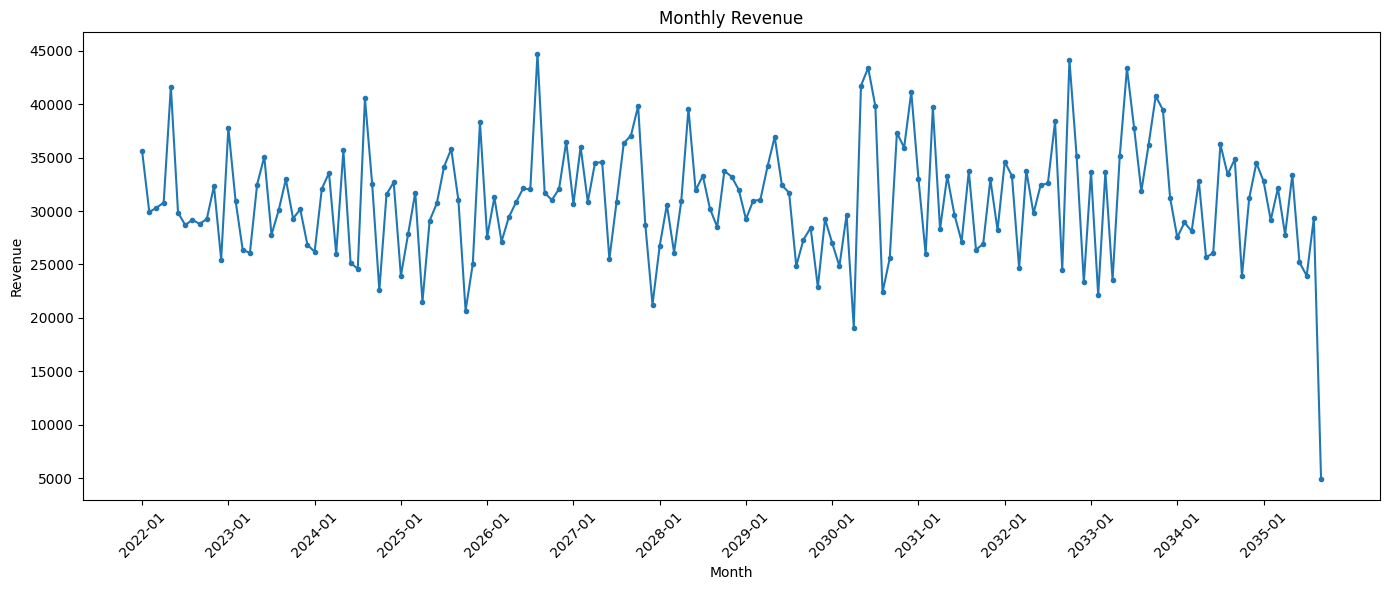

In [8]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    marker="o",
    markersize=3
)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")

# Show one label every 12 months
plt.xticks(
    range(0, len(monthly_revenue), 12),
    monthly_revenue.index[::12],
    rotation=45
)

plt.tight_layout()
plt.show()

In [9]:
category_revenue = df.groupby("product_category")["revenue"].sum()

category_revenue

product_category
Beauty          765860.88
Clothing       1531931.72
Electronics    1829899.22
Home            982083.92
Name: revenue, dtype: float64

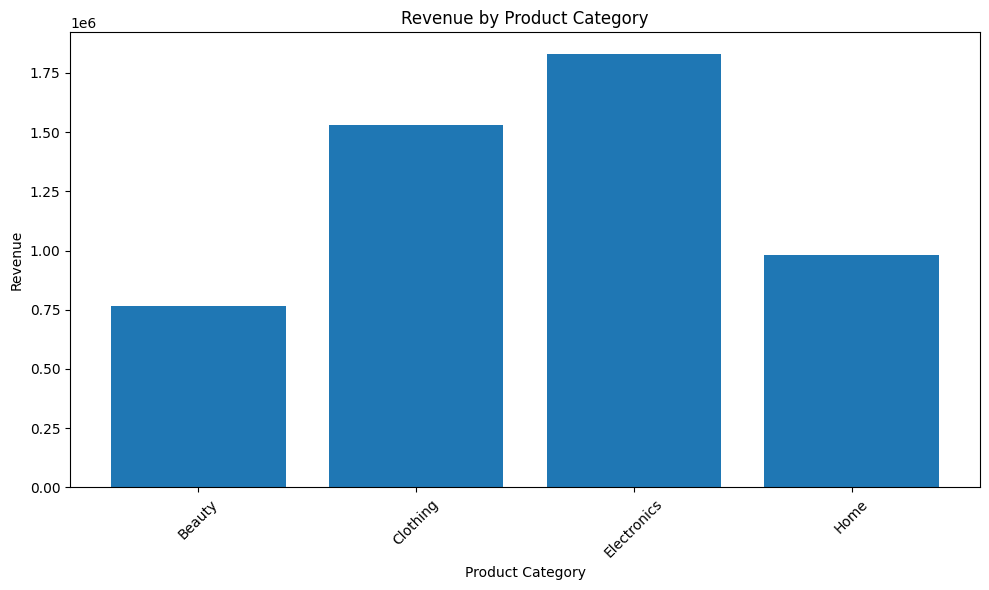

In [10]:
plt.figure(figsize=(10, 6))

plt.bar(
    category_revenue.index,
    category_revenue.values
)

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

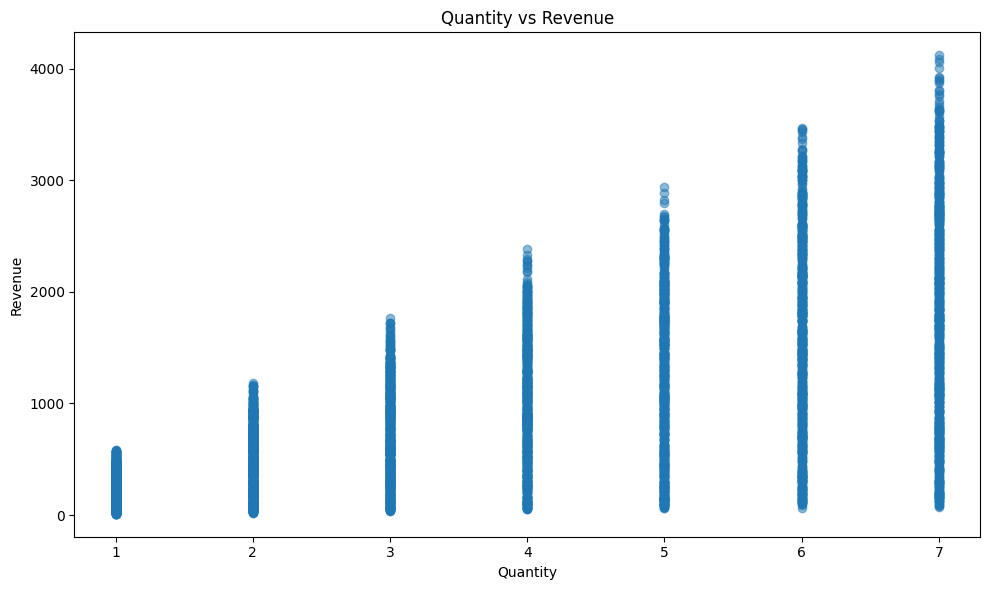

In [15]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["quantity"],
    df["revenue"],
    alpha=0.5
)

plt.title("Quantity vs Revenue")
plt.xlabel("Quantity")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

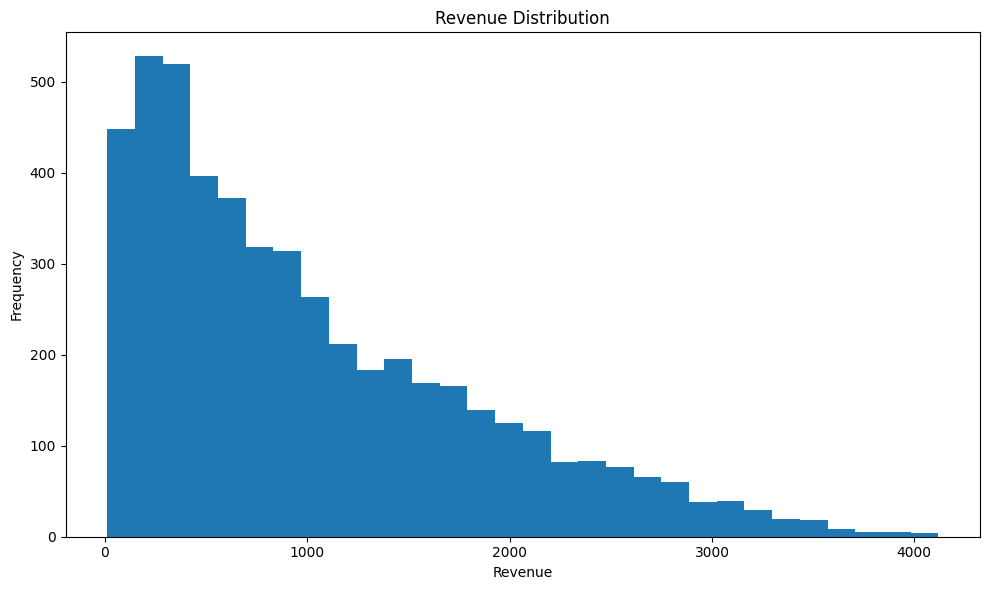

In [16]:
plt.figure(figsize=(10, 6))

plt.hist(df["revenue"], bins=30)

plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [17]:
numeric_columns = [
    "quantity",
    "unit_price",
    "discount",
    "delivery_days",
    "customer_rating",
    "revenue"
]

correlation = df[numeric_columns].corr()

correlation

,quantity,unit_price,discount,delivery_days,customer_rating,revenue
quantity,1.000000,0.001498,-0.004302,-0.008748,0.019168,0.623564
unit_price,0.001498,1.000000,0.013215,0.015623,0.005025,0.678032
discount,-0.004302,0.013215,1.000000,-0.000382,0.012776,-0.139296
delivery_days,-0.008748,0.015623,-0.000382,1.000000,-0.017625,0.005444
customer_rating,0.019168,0.005025,0.012776,-0.017625,1.000000,0.012446
revenue,0.623564,0.678032,-0.139296,0.005444,0.012446,1.000000


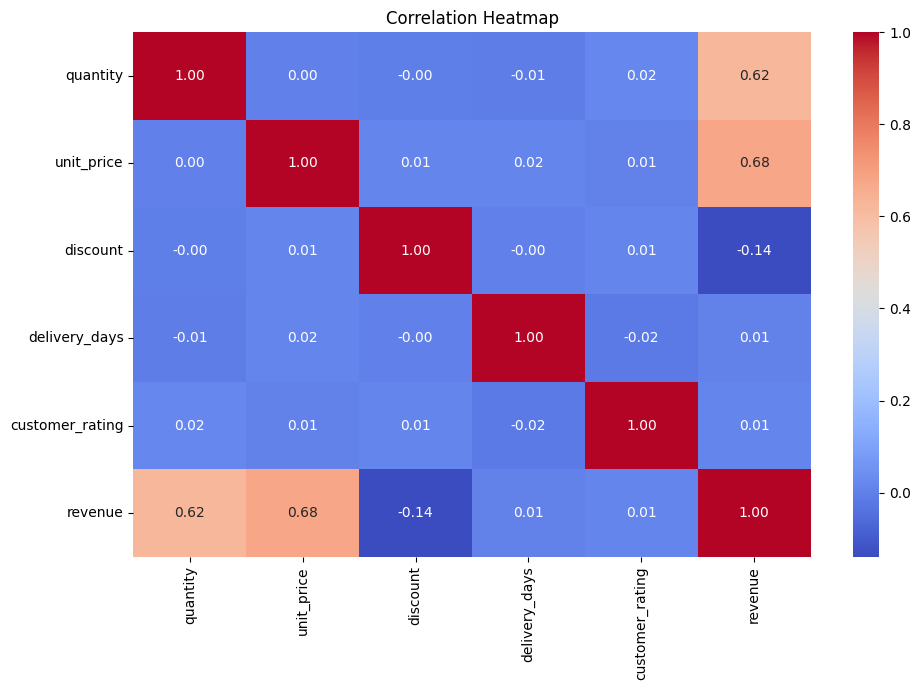

In [18]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

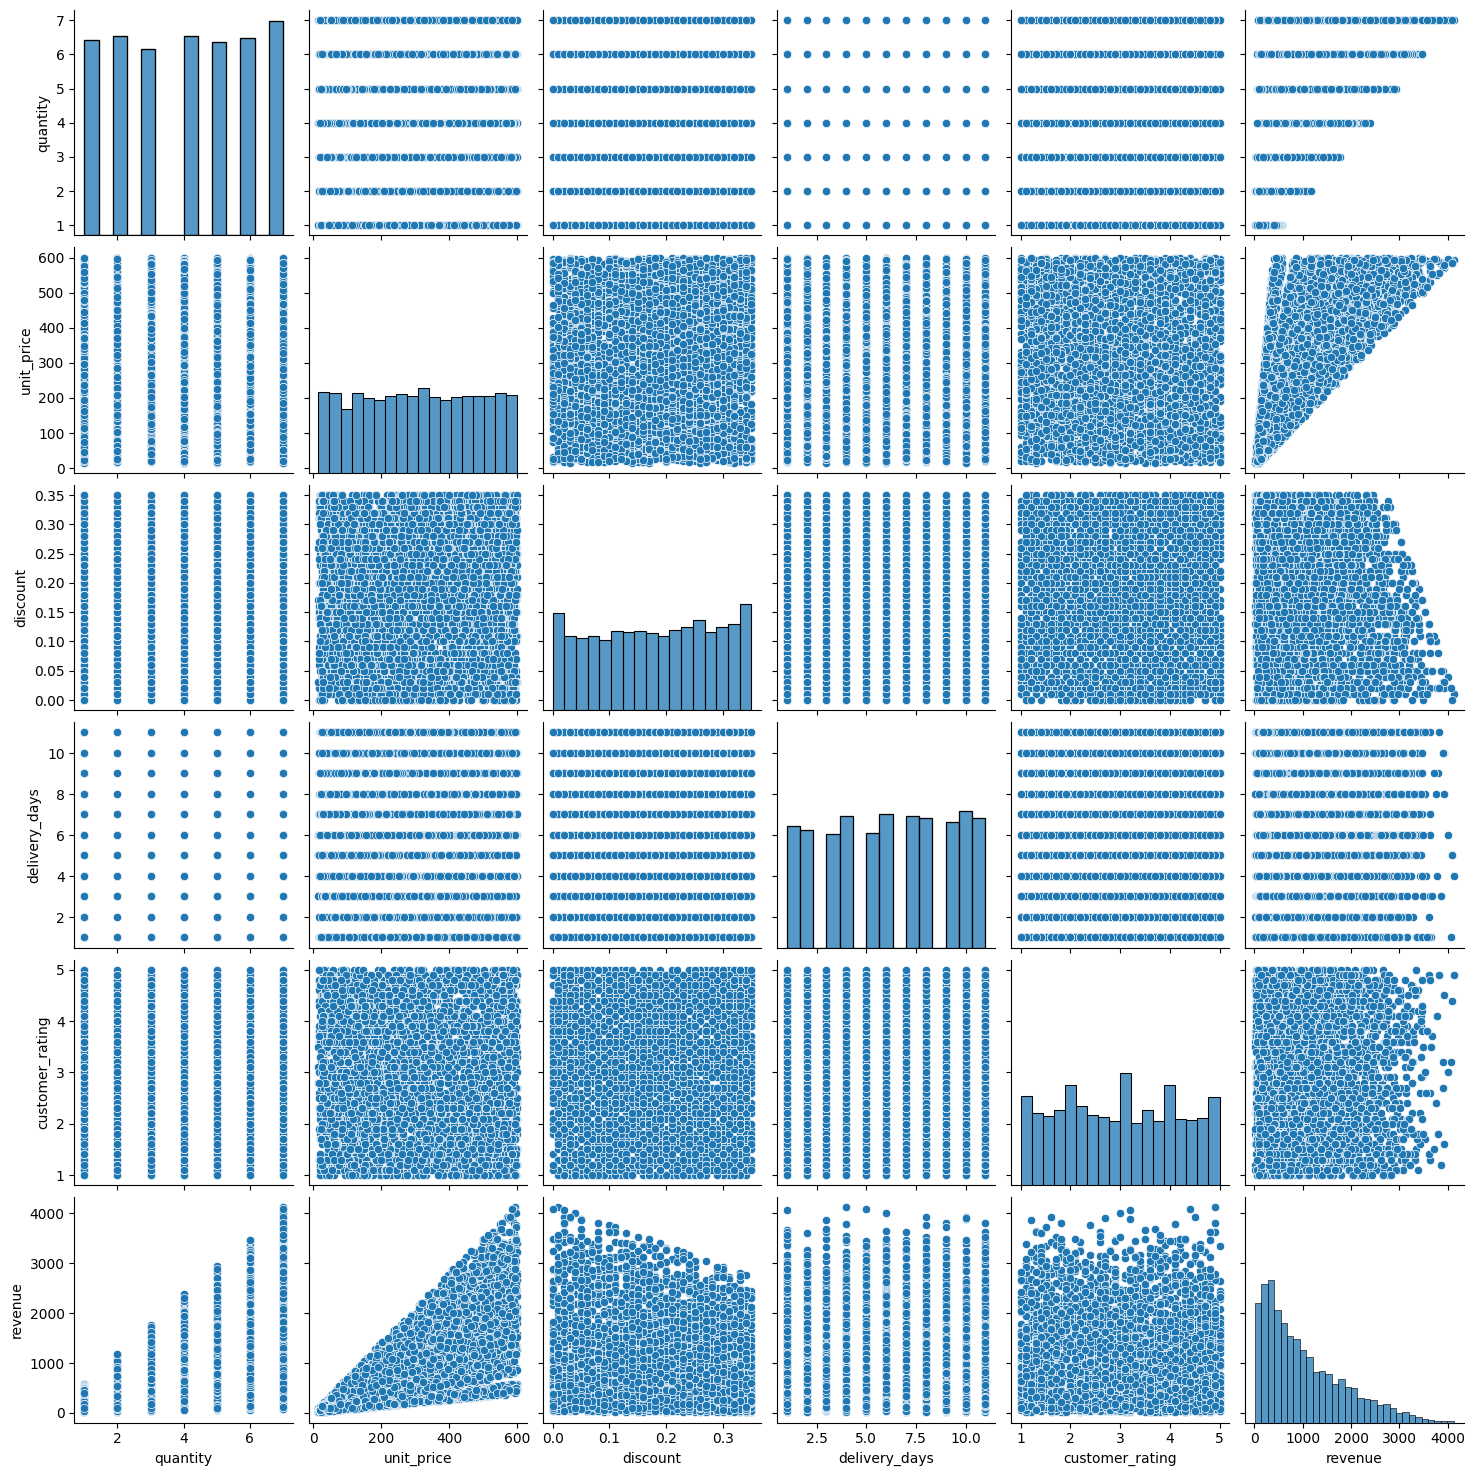

In [19]:
sns.pairplot(
    df[
        [
            "quantity",
            "unit_price",
            "discount",
            "delivery_days",
            "customer_rating",
            "revenue"
        ]
    ]
)

plt.show()

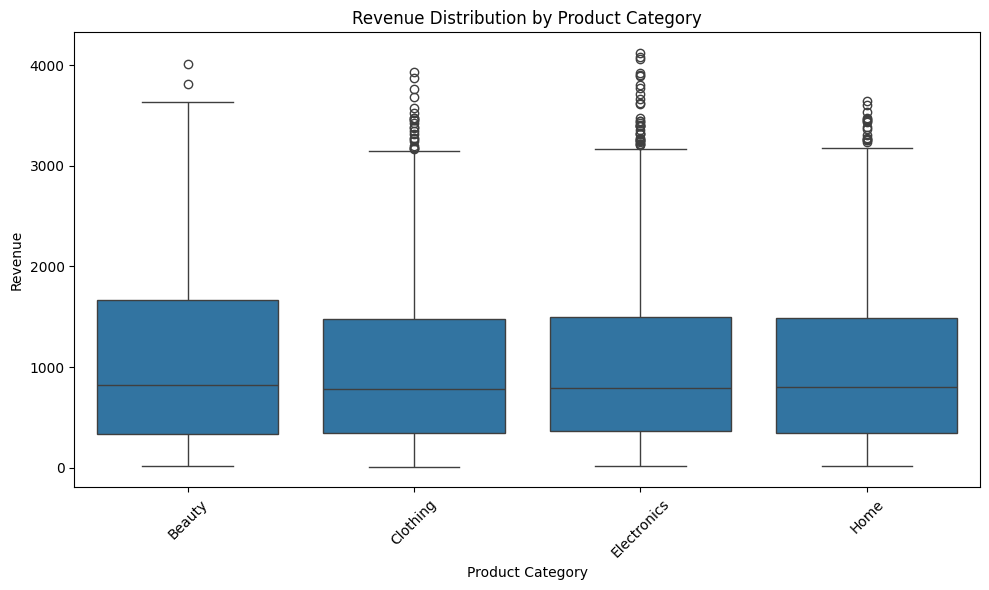

In [20]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    x="product_category",
    y="revenue",
    data=df
)

plt.title("Revenue Distribution by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
fig = px.line(
    x=monthly_revenue.index,
    y=monthly_revenue.values,
    markers=True,
    title="Interactive Monthly Revenue"
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Revenue"
)

fig.show()

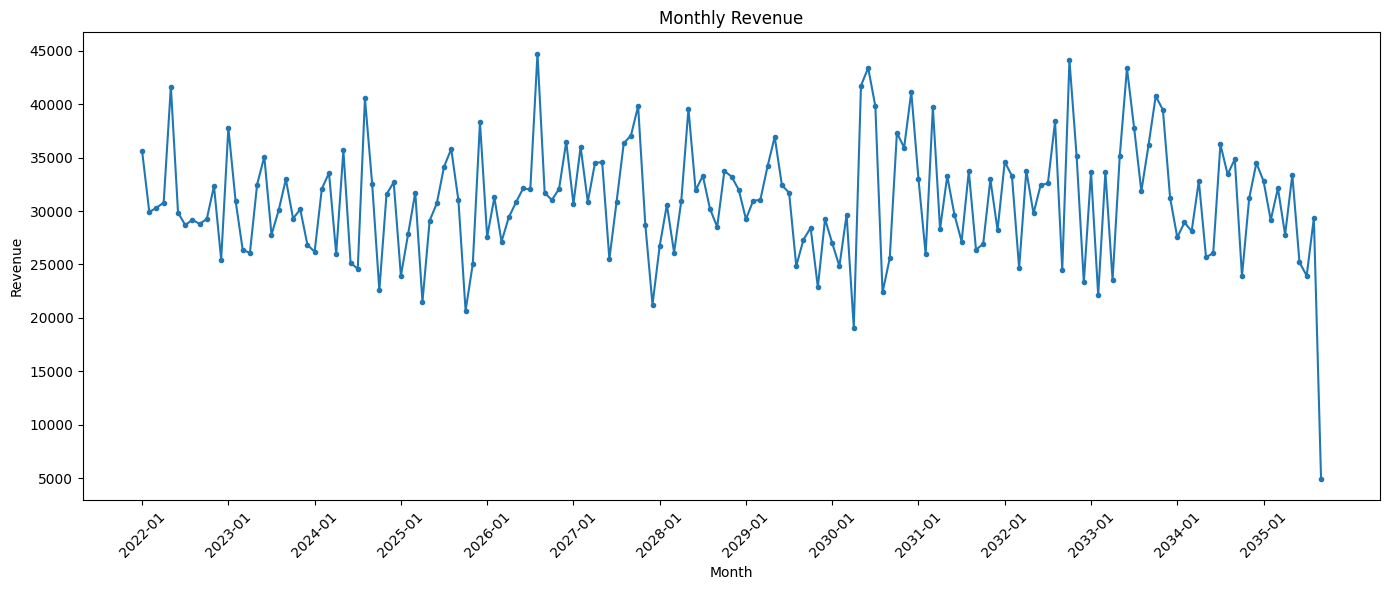

In [22]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    marker="o",
    markersize=3
)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(
    range(0, len(monthly_revenue), 12),
    monthly_revenue.index[::12],
    rotation=45
)

plt.tight_layout()

plt.savefig(
    "../reports/monthly_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [23]:
fig.write_html("../reports/interactive_monthly_revenue.html")